In [1]:
# 1. IMPORT LIBRARY LENGKAP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import HistGradientBoostingClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# 2. LOAD DATASET

df = pd.read_csv('../dataset/predictive_maintenance.csv')

print("=== 5 Baris Pertama Dataset ===")
display(df.head())
print("=== Info Dataset ===")
df.info()

=== 5 Baris Pertama Dataset ===


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


=== Info Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [2]:
# 3. PREPROCESSING
print("=== Memulai Preprocessing ===")

# Buang kolom yang tidak relevan
df_bersih = df.drop(columns=['UDI', 'Product ID', 'Target'])

# Ubah teks 'Type' jadi angka
le_type = LabelEncoder()
df_bersih['Type'] = le_type.fit_transform(df_bersih['Type'])

# Ubah teks 'Failure Type' (Target) jadi angka 0-5 (Wajib untuk XGBoost)
le_target = LabelEncoder()
df_bersih['Failure Type'] = le_target.fit_transform(df_bersih['Failure Type'])

# Pisahkan Input/Label (X) dan Output/Target (y)
X = df_bersih.drop(columns=['Failure Type'])
y = df_bersih['Failure Type']

print("Preprocessing Selesai! Data siap dibagi.")
display(df_bersih.head())

=== Memulai Preprocessing ===
Preprocessing Selesai! Data siap dibagi.


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type
0,2,298.1,308.6,1551,42.8,0,1
1,1,298.2,308.7,1408,46.3,3,1
2,1,298.1,308.5,1498,49.4,5,1
3,1,298.2,308.6,1433,39.5,7,1
4,1,298.2,308.7,1408,40.0,9,1


C:\Users\Hi\AppData\Local\Temp\ipykernel_5484\1833145525.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=kelas_teks,


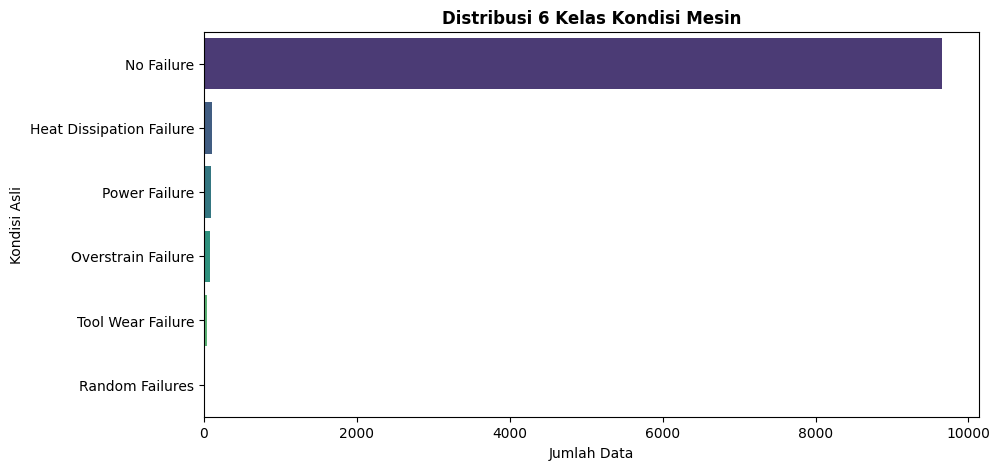

In [3]:
# 4. EDA: GRAFIK DISTRIBUSI KELAS KERUSAKAN
plt.figure(figsize=(10, 5))

# Kita pakai teks asli untuk grafik agar mudah dibaca
kelas_teks = le_target.inverse_transform(df_bersih['Failure Type'])

sns.countplot(y=kelas_teks, 
              order=pd.Series(kelas_teks).value_counts().index, 
              palette='viridis')

plt.title('Distribusi 6 Kelas Kondisi Mesin', fontweight='bold')
plt.xlabel('Jumlah Data')
plt.ylabel('Kondisi Asli')
plt.show()

In [4]:
# 5A. PEMBAGIAN DATA RASIO 70:30
print("=== MENYIAPKAN DATA 70:30 ===")
X_train_70, X_test_70, y_train_70, y_test_70 = train_test_split(X, y, test_size=0.3, random_state=42)

scaler_70 = StandardScaler()
X_train_70_scaled = scaler_70.fit_transform(X_train_70)
X_test_70_scaled = scaler_70.transform(X_test_70)

print(f"Data 70:30 Berhasil Dibuat!")
print(f"Jumlah Data Training: {X_train_70.shape[0]} baris")
print(f"Jumlah Data Testing  : {X_test_70.shape[0]} baris\n")

=== MENYIAPKAN DATA 70:30 ===
Data 70:30 Berhasil Dibuat!
Jumlah Data Training: 7000 baris
Jumlah Data Testing  : 3000 baris



In [5]:
# 5B. PEMBAGIAN DATA RASIO 80:20
print("=== MENYIAPKAN DATA 80:20 ===")
X_train_80, X_test_80, y_train_80, y_test_80 = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_80 = StandardScaler()
X_train_80_scaled = scaler_80.fit_transform(X_train_80)
X_test_80_scaled = scaler_80.transform(X_test_80)

print(f"Data 80:20 Berhasil Dibuat!")
print(f"Jumlah Data Training: {X_train_80.shape[0]} baris")
print(f"Jumlah Data Testing  : {X_test_80.shape[0]} baris\n")

=== MENYIAPKAN DATA 80:20 ===
Data 80:20 Berhasil Dibuat!
Jumlah Data Training: 8000 baris
Jumlah Data Testing  : 2000 baris



In [6]:
# 5C. PEMBAGIAN DATA RASIO 90:10
print("=== MENYIAPKAN DATA 90:10 ===")
X_train_90, X_test_90, y_train_90, y_test_90 = train_test_split(X, y, test_size=0.1, random_state=42)

scaler_90 = StandardScaler()
X_train_90_scaled = scaler_90.fit_transform(X_train_90)
X_test_90_scaled = scaler_90.transform(X_test_90)

print(f"Data 90:10 Berhasil Dibuat!")
print(f"Jumlah Data Training: {X_train_90.shape[0]} baris")
print(f"Jumlah Data Testing  : {X_test_90.shape[0]} baris\n")

=== MENYIAPKAN DATA 90:10 ===
Data 90:10 Berhasil Dibuat!
Jumlah Data Training: 9000 baris
Jumlah Data Testing  : 1000 baris



In [7]:
# 6. MELATIH 3 MODEL PADA SEMUA RASIO
models = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss', n_estimators=300, max_depth=5, learning_rate=0.1),
    "HistGradient": HistGradientBoostingClassifier(random_state=42, class_weight='balanced', max_iter=250, learning_rate=0.1, max_depth=6, max_bins=255),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, class_weight='balanced', n_estimators=300, max_depth=None, max_features='sqrt', min_samples_split=4, n_jobs=-1)
}

# Mengumpulkan semua variabel split dari atas agar mudah dieksekusi bersamaan
kumpulan_data = {
    '70:30': (X_train_70_scaled, X_test_70_scaled, y_train_70, y_test_70),
    '80:20': (X_train_80_scaled, X_test_80_scaled, y_train_80, y_test_80),
    '90:10': (X_train_90_scaled, X_test_90_scaled, y_train_90, y_test_90)
}

hasil_eksperimen = []
print("=== MEMULAI PELATIHAN AI ===")

for rasio, (X_tr, X_ts, y_tr, y_ts) in kumpulan_data.items():
    print(f"Sedang menguji AI di rasio {rasio}...")
    for nama_model, model in models.items():
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_ts)
        
        akurasi = accuracy_score(y_ts, y_pred)
        presisi = precision_score(y_ts, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_ts, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_ts, y_pred, average='weighted', zero_division=0)
        
        hasil_eksperimen.append({
            'Rasio Data': rasio, 'Algoritma': nama_model,
            'Accuracy': akurasi * 100, 'Precision': presisi * 100,
            'Recall': recall * 100, 'F1-Score': f1 * 100
        })

print("\nPelatihan Selesai! Cek hasilnya di cell bawah.")

=== MEMULAI PELATIHAN AI ===
Sedang menguji AI di rasio 70:30...
Sedang menguji AI di rasio 80:20...
Sedang menguji AI di rasio 90:10...

Pelatihan Selesai! Cek hasilnya di cell bawah.


=== TABEL EVALUASI LENGKAP ===


,Rasio Data,Algoritma,Accuracy,Precision,Recall,F1-Score
0,90:10,HistGradient,98.40,98.14,98.40,98.20
1,90:10,XGBoost,98.20,97.81,98.20,97.95
2,90:10,ExtraTrees,98.00,97.91,98.00,97.62
3,80:20,HistGradient,98.30,97.85,98.30,98.06
4,80:20,XGBoost,98.20,97.43,98.20,97.80
5,80:20,ExtraTrees,98.10,97.73,98.10,97.66
6,70:30,XGBoost,98.63,98.01,98.63,98.30
7,70:30,HistGradient,98.57,98.14,98.57,98.34
8,70:30,ExtraTrees,98.03,97.52,98.03,97.58


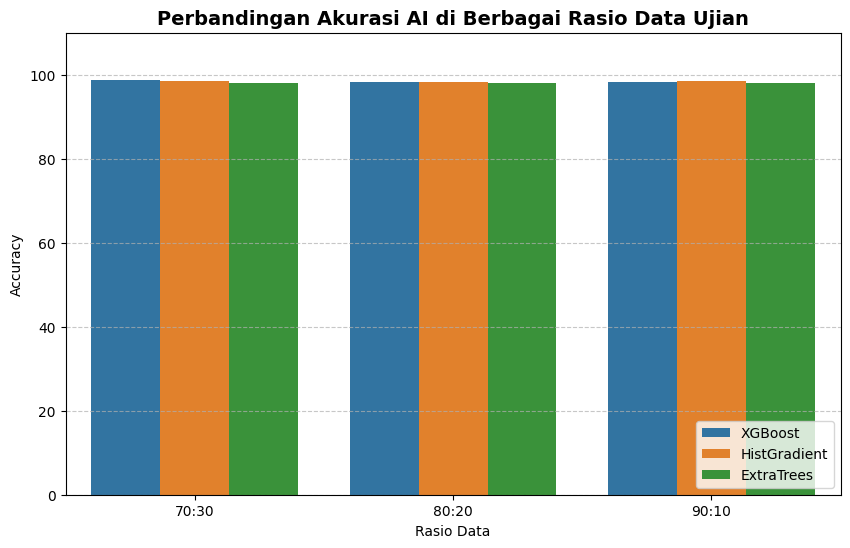

In [8]:
# 7. MENAMPILKAN TABEL DAN GRAFIK HASIL UJIAN AI
df_hasil = pd.DataFrame(hasil_eksperimen)

print("=== TABEL EVALUASI LENGKAP ===")
display(df_hasil.round(2).sort_values(by=['Rasio Data', 'Accuracy'], ascending=[False, False]).reset_index(drop=True))

plt.figure(figsize=(10, 6))
sns.barplot(data=df_hasil, x='Rasio Data', y='Accuracy', hue='Algoritma')

plt.title('Perbandingan Akurasi AI di Berbagai Rasio Data Ujian', fontsize=14, fontweight='bold')
plt.ylim(0, 110)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [9]:
# 8. SIMULASI PENGUJIAN DATA BARU DENGAN 100% DATA
print("=== SIMULASI DETEKSI KERUSAKAN MESIN ===")

# Standarisasi 100% data
scaler_final = StandardScaler()
X_scaled_full = scaler_final.fit_transform(X)

# Melatih ulang Trio AI dengan 100% data agar wawasannya penuh
models_final = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss'),
    "HistGradient": HistGradientBoostingClassifier(random_state=42, class_weight='balanced', max_iter=200),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, class_weight='balanced', n_estimators=100)
}

print("🛠️ Mempersiapkan AI dengan 100% Data Pabrik...")
for nama, model in models_final.items():
    model.fit(X_scaled_full, y)

# Input Angka Baru dari Sensor
data_baru = pd.DataFrame({
    'Type': [0],                        # Kualitas Low (Rentan)
    'Air temperature [K]': [244],     
    'Process temperature [K]': [238], 
    'Rotational speed [rpm]': [123],   # Putaran mesin agak tertahan
    'Torque [Nm]': [2000],              # Tarikan/Beban SANGAT TINGGI
    'Tool wear [min]': [200]            # Alat sudah lumayan lama dipakai
})

print("\n📡 Membaca Data Sensor Masuk:")
display(data_baru)

# Standarisasi input baru dan prediksi
data_baru_scaled = scaler_final.transform(data_baru)

print("\n🚨 HASIL MASING-MASING MODEL")
for nama, model in models_final.items():
    tebakan_angka = model.predict(data_baru_scaled)
    tebakan_teks = le_target.inverse_transform(tebakan_angka)
    print(f"[{nama}] menebak: >> {tebakan_teks[0].upper()} <<")

=== SIMULASI DETEKSI KERUSAKAN MESIN ===
🛠️ Mempersiapkan AI dengan 100% Data Pabrik...

📡 Membaca Data Sensor Masuk:


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,0,244,238,123,2000,200



🚨 HASIL MASING-MASING MODEL
[XGBoost] menebak: >> POWER FAILURE <<
[HistGradient] menebak: >> POWER FAILURE <<
[ExtraTrees] menebak: >> POWER FAILURE <<


=== 1. PERSIAPAN AI & DATA ===
=== 2. MEMULAI PELATIHAN AI ===
Sedang menguji AI di rasio 70:30...
Sedang menguji AI di rasio 80:20...
Sedang menguji AI di rasio 90:10...

=== 3. HASIL EVALUASI AKHIR ===
--- TABEL METRIK LENGKAP ---


,Rasio Data,Algoritma,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,90:10,XGBoost,97.60,52.95,65.84,57.76
1,90:10,HistGradient,98.40,63.72,61.25,60.44
2,90:10,ExtraTrees,98.00,75.90,50.58,55.60
3,80:20,XGBoost,97.35,51.70,60.98,55.77
4,80:20,HistGradient,98.30,62.01,60.49,60.86
5,80:20,ExtraTrees,98.10,73.35,49.41,54.34
6,70:30,XGBoost,97.97,58.50,64.20,61.07
7,70:30,HistGradient,98.57,63.67,59.71,61.42
8,70:30,ExtraTrees,98.03,69.34,44.98,52.29


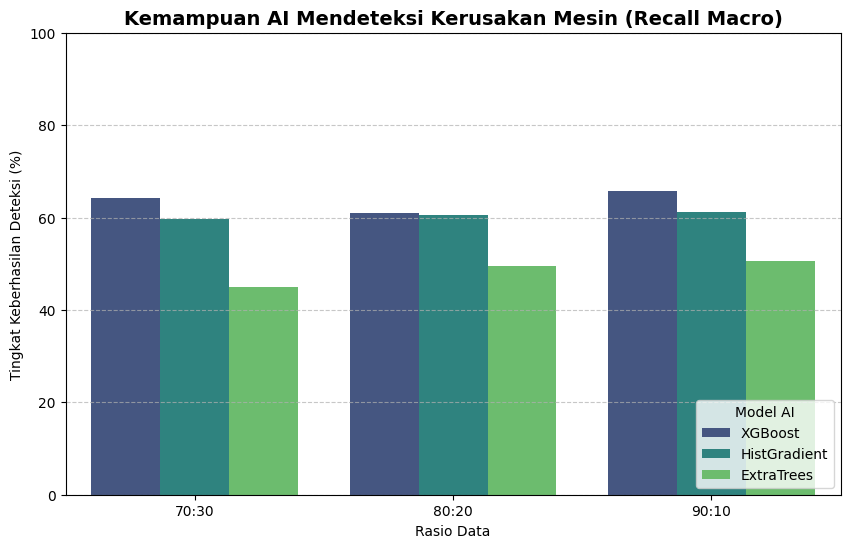

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== 1. PERSIAPAN AI & DATA ===")
# 1. Definisi Model
models = {
    "XGBoost": XGBClassifier(random_state=42, eval_metric='mlogloss', n_estimators=300, max_depth=5, learning_rate=0.1),
    "HistGradient": HistGradientBoostingClassifier(random_state=42, class_weight='balanced', max_iter=250, learning_rate=0.1, max_depth=6, max_bins=255),
    "ExtraTrees": ExtraTreesClassifier(random_state=42, class_weight='balanced', n_estimators=300, max_depth=None, max_features='sqrt', min_samples_split=4, n_jobs=-1)
}

# 2. Murni pakai variabel aslimu yang sudah aman dari error
kumpulan_data = {
    '70:30': (X_train_70_scaled, X_test_70_scaled, y_train_70, y_test_70),
    '80:20': (X_train_80_scaled, X_test_80_scaled, y_train_80, y_test_80),
    '90:10': (X_train_90_scaled, X_test_90_scaled, y_train_90, y_test_90)
}

hasil_eksperimen = []
print("=== 2. MEMULAI PELATIHAN AI ===")

for rasio, (X_tr, X_ts, y_tr, y_ts) in kumpulan_data.items():
    print(f"Sedang menguji AI di rasio {rasio}...")
    
    # Hitung bobot manual khusus untuk XGBoost
    bobot_sampel_xgb = compute_sample_weight(class_weight='balanced', y=y_tr)
    
    for nama_model, model in models.items():
        if nama_model == "XGBoost":
            model.fit(X_tr, y_tr, sample_weight=bobot_sampel_xgb)
        else:
            model.fit(X_tr, y_tr)
            
        y_pred = model.predict(X_ts)
        
        # PERHITUNGAN METRIK (Pakai MACRO)
        akurasi = accuracy_score(y_ts, y_pred)
        presisi = precision_score(y_ts, y_pred, average='macro', zero_division=0)
        recall = recall_score(y_ts, y_pred, average='macro', zero_division=0)
        f1 = f1_score(y_ts, y_pred, average='macro', zero_division=0)
        
        hasil_eksperimen.append({
            'Rasio Data': rasio, 'Algoritma': nama_model,
            'Accuracy': akurasi * 100, 'Precision (Macro)': presisi * 100,
            'Recall (Macro)': recall * 100, 'F1-Score (Macro)': f1 * 100
        })

print("\n=== 3. HASIL EVALUASI AKHIR ===")
df_hasil = pd.DataFrame(hasil_eksperimen)

# Menampilkan Tabel
print("--- TABEL METRIK LENGKAP ---")
display(df_hasil.round(2).sort_values(by=['Rasio Data', 'Recall (Macro)'], ascending=[False, False]).reset_index(drop=True))

# Menampilkan Grafik
plt.figure(figsize=(10, 6))
sns.barplot(data=df_hasil, x='Rasio Data', y='Recall (Macro)', hue='Algoritma', palette='viridis')

plt.title('Kemampuan AI Mendeteksi Kerusakan Mesin (Recall Macro)', fontsize=14, fontweight='bold')
plt.ylim(0, 100)
plt.ylabel('Tingkat Keberhasilan Deteksi (%)')
plt.legend(loc='lower right', title='Model AI')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== MEMULAI GENERASI CONFUSION MATRIX UNTUK SEMUA SPLIT ===


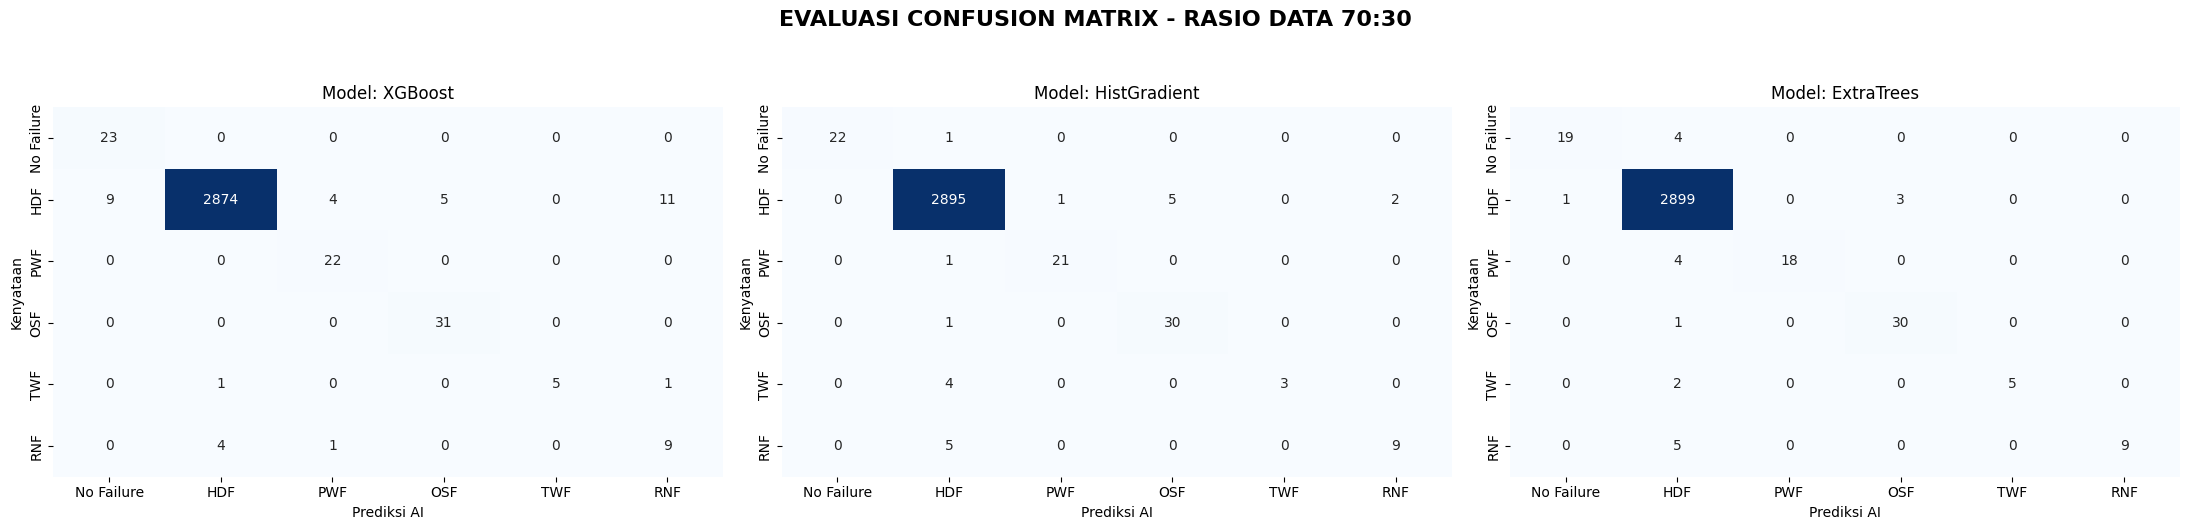

----------------------------------------------------------------------------------------------------


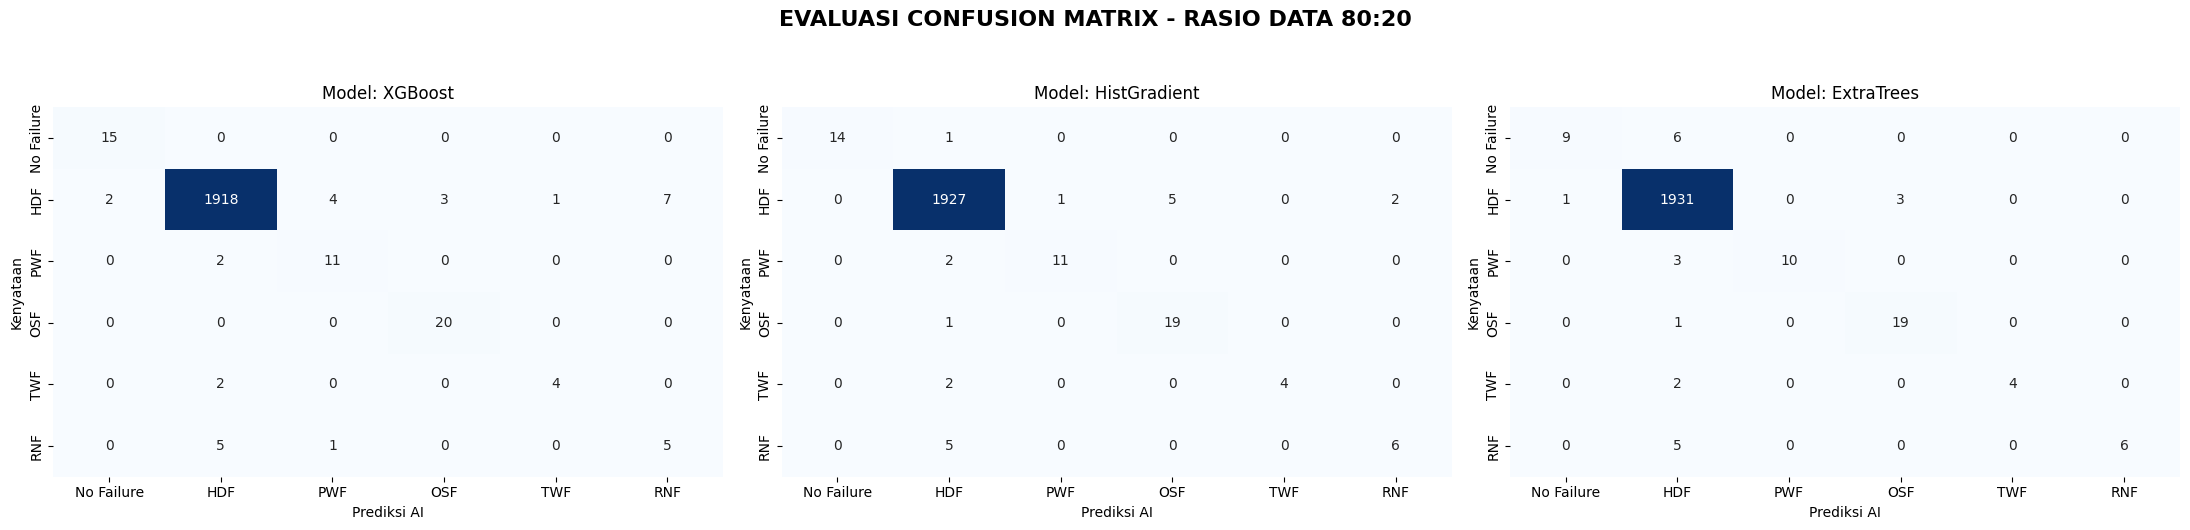

----------------------------------------------------------------------------------------------------


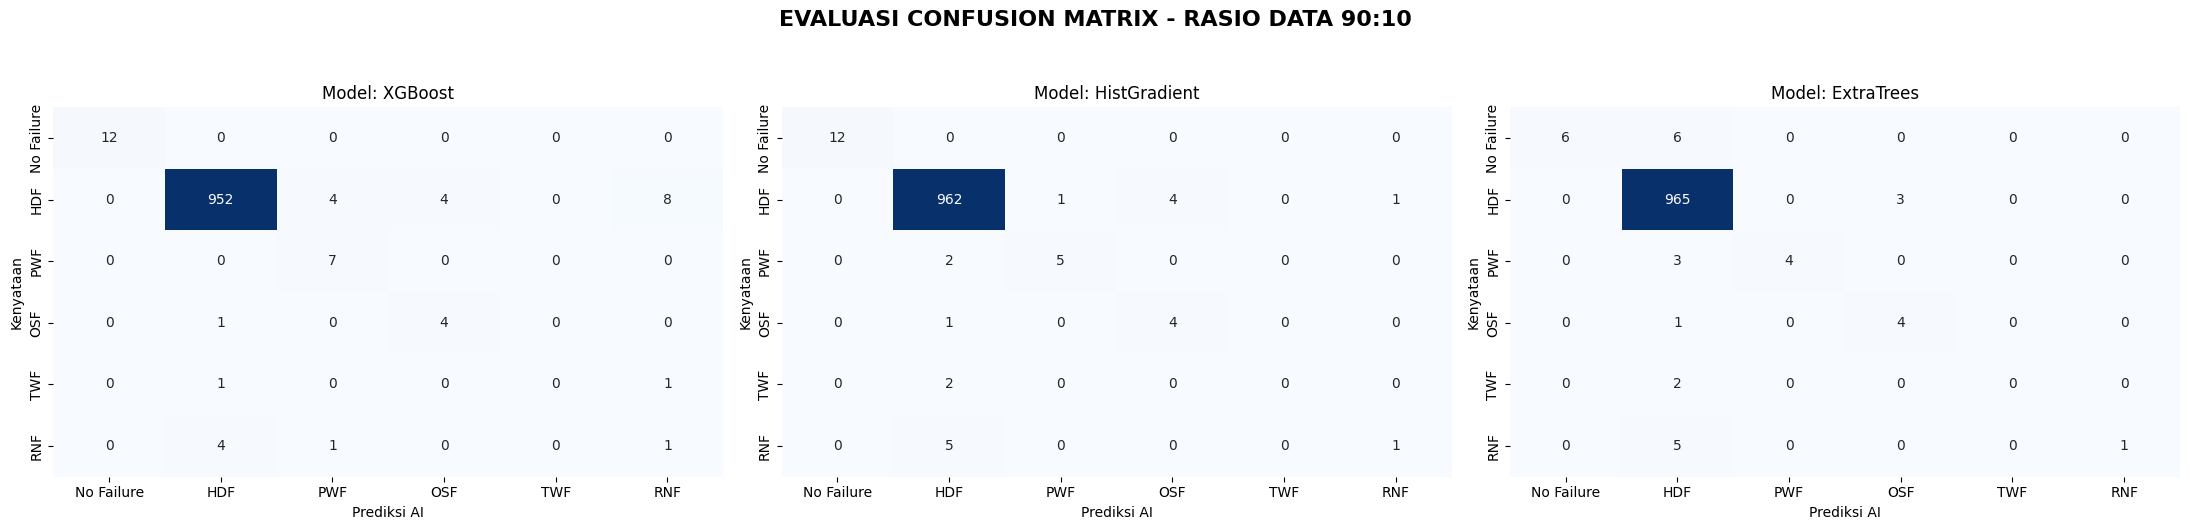

----------------------------------------------------------------------------------------------------


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Definisi label kategori (Pastikan urutannya sesuai dengan label 0-5 di dataset Anda)
label_names = ['No Failure', 'HDF', 'PWF', 'OSF', 'TWF', 'RNF']

print("=== MEMULAI GENERASI CONFUSION MATRIX UNTUK SEMUA SPLIT ===")

# Loop melalui setiap rasio data
for rasio, (X_tr, X_ts, y_tr, y_ts) in kumpulan_data.items():
    # Membuat satu baris berisi 3 kolom (untuk 3 model) per rasio
    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    fig.suptitle(f"EVALUASI CONFUSION MATRIX - RASIO DATA {rasio}", fontsize=16, fontweight='bold', y=1.05)
    
    for i, (nama_model, model) in enumerate(models.items()):
        # Model melakukan prediksi pada data test sesuai rasionya
        y_pred = model.predict(X_ts)
        
        # Hitung Matrix
        cm = confusion_matrix(y_ts, y_pred)
        
        # Visualisasi dengan Heatmap
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], 
                    xticklabels=label_names, yticklabels=label_names, cbar=False)
        
        axes[i].set_title(f"Model: {nama_model}", fontsize=12)
        axes[i].set_xlabel('Prediksi AI')
        axes[i].set_ylabel('Kenyataan')

    plt.tight_layout()
    plt.show()
    print("-" * 100)